# Marine Heatwaves in the Indian Ocean (2021-2025)

## Project Goal
Build a simple but strong ML pipeline for marine heatwave (MHW) detection using NOAA OISST daily SST.

## Core Definition (paper-consistent)
A day is labeled as MHW if:
- SST > 90th percentile threshold estimated from training years only
- Condition persists for at least 5 consecutive days

## Models
- Logistic Regression (baseline)
- Random Forest (main model)

## Report Figures this notebook creates
- SST trend over time (Indian Ocean mean)
- MHW occurrences over time
- Confusion matrices and model comparison chart

In [1]:
# Imports and plotting setup
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

# Project paths
project_root = Path.cwd()
dataset_dir = project_root / "dataset"
output_dir = project_root / "outputs"
output_dir.mkdir(exist_ok=True)

# Indian Ocean bounding box (simple project-friendly definition)
# Latitude: 30S to 30N, Longitude: 20E to 120E
lat_min, lat_max = -30, 30
lon_min, lon_max = 20, 120

print("Dataset folder:", dataset_dir)
print("Output folder:", output_dir)

Dataset folder: c:\Users\sharv\Downloads\Sem 6\ocean\ocean projjj\dataset
Output folder: c:\Users\sharv\Downloads\Sem 6\ocean\ocean projjj\outputs


In [10]:
# Load NOAA OISST daily files and inspect
nc_files = sorted(dataset_dir.glob("sst.day.mean.*.nc"))
print("Found files:")
for f in nc_files:
    print("-", f.name)

if not nc_files:
    raise FileNotFoundError("No NetCDF files found in dataset folder")

# Dask-free multi-file loading (friendly for simple local setup)
ds_list = [xr.open_dataset(f) for f in nc_files]
ds = xr.concat(ds_list, dim="time").sortby("time")
print(ds)

# Keep only needed variable
if "sst" not in ds.variables:
    raise KeyError("'sst' variable not found in dataset")

# Handle longitude convention (0..360 vs -180..180)
if ds["lon"].max() > 180:
    ds = ds.assign_coords(lon=((ds.lon + 360) % 360)).sortby("lon")

# Subset Indian Ocean and compute area-weighted regional mean SST time series
regional = ds["sst"].sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))
weights = np.cos(np.deg2rad(regional["lat"]))
indian_ocean_sst = regional.weighted(weights).mean(dim=("lat", "lon")).to_series()
indian_ocean_sst.name = "sst"
indian_ocean_sst.index = pd.to_datetime(indian_ocean_sst.index)

print("\nRegional SST series shape:", indian_ocean_sst.shape)
print(indian_ocean_sst.head())

Found files:
- sst.day.mean.2021.nc
- sst.day.mean.2022.nc
- sst.day.mean.2023.nc
- sst.day.mean.2024.nc
- sst.day.mean.2025.nc
<xarray.Dataset> Size: 8GB
Dimensions:  (time: 1826, lat: 720, lon: 1440)
Coordinates:
  * time     (time) datetime64[ns] 15kB 2021-01-01 2021-01-02 ... 2025-12-31
  * lat      (lat) float32 3kB -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 6kB 0.125 0.375 0.625 0.875 ... 359.4 359.6 359.9
Data variables:
    sst      (time, lat, lon) float32 8GB nan nan nan nan ... -1.8 -1.8 -1.8
Attributes:
    Conventions:    CF-1.5
    title:          NOAA/NCEI 1/4 Degree Daily Optimum Interpolation Sea Surf...
    institution:    NOAA/National Centers for Environmental Information
    source:         NOAA/NCEI https://www.ncei.noaa.gov/data/sea-surface-temp...
    References:     https://www.psl.noaa.gov/data/gridded/data.noaa.oisst.v2....
    dataset_title:  NOAA Daily Optimum Interpolation Sea Surface Temperature
    version:        Versio

In [ ]:
# Feature engineering + MHW labeling rule

df = pd.DataFrame(index=indian_ocean_sst.index)
df["sst"] = indian_ocean_sst.values
df = df.sort_index().dropna()

# Time features
df["month"] = df.index.month
df["dayofyear"] = df.index.dayofyear

# 7-day rolling mean to provide temporal context for ML
df["sst_roll7"] = df["sst"].rolling(7, min_periods=1).mean()

# Train-test split by time (no leakage):
# Base model: Train 2023-2024, Test 2025
train_mask = df.index.year <= 2024
test_mask = df.index.year == 2025

# Single scalar threshold estimated from TRAIN years only
q90 = df.loc[train_mask, "sst"].quantile(0.90)
df["above_q90"] = (df["sst"] > q90).astype(int)

# Label heatwave runs: >=5 consecutive days above threshold
runs = (df["above_q90"] != df["above_q90"].shift()).cumsum()
run_lengths = df.groupby(runs)["above_q90"].transform("sum")
df["heatwave"] = ((df["above_q90"] == 1) & (run_lengths >= 5)).astype(int)

print(f"Indian Ocean region used in code: lat [{lat_min}, {lat_max}], lon [{lon_min}, {lon_max}]")
print(f"Training-year-only q90 threshold (single constant): {q90:.3f} degC")
print(df[["sst", "above_q90", "heatwave"]].head(12))
print("\nClass balance:")
print(df["heatwave"].value_counts(normalize=True).rename("fraction"))

# Save labeled dataset
df.to_csv(output_dir / "indian_ocean_mhw_labeled.csv", index=True)
print("Saved:", output_dir / "indian_ocean_mhw_labeled.csv")

Q90 threshold (train only): 28.366 degC
                  sst  above_q90  heatwave
time                                      
2023-01-01  27.078386          0         0
2023-01-02  27.065748          0         0
2023-01-03  27.047113          0         0
2023-01-04  27.035542          0         0
2023-01-05  27.018641          0         0
2023-01-06  26.996462          0         0
2023-01-07  26.988691          0         0
2023-01-08  26.997063          0         0
2023-01-09  27.025745          0         0
2023-01-10  27.058416          0         0
2023-01-11  27.083681          0         0
2023-01-12  27.093681          0         0

Class balance:
heatwave
0    0.886861
1    0.113139
Name: fraction, dtype: float64
Saved: c:\Users\sharv\Downloads\Sem 6\ocean\ocean projjj\outputs\indian_ocean_mhw_labeled.csv


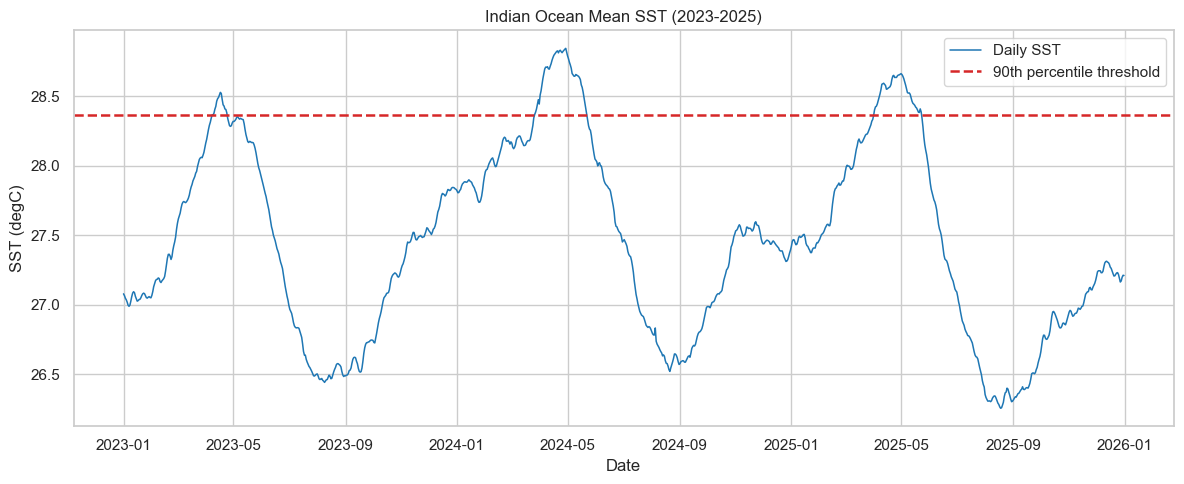

Saved: c:\Users\sharv\Downloads\Sem 6\ocean\ocean projjj\outputs\sst_trend_indian_ocean.png


In [ ]:
# EDA 1: SST trend over time + threshold line

plot_year_start = int(df.index.year.min())
plot_year_end = int(df.index.year.max())

fig, ax = plt.subplots()
ax.plot(df.index, df["sst"], color="#1f77b4", linewidth=1.1, label="Daily SST")
ax.axhline(
    q90,
    color="#d62728",
    linestyle="--",
    linewidth=1.8,
    label="Training-year q90 threshold (single constant)",
)
ax.set_title(f"Indian Ocean Mean SST ({plot_year_start}-{plot_year_end})")
ax.set_xlabel("Date")
ax.set_ylabel("SST (degC)")
ax.legend(loc="best")
plt.tight_layout()
plt.savefig(output_dir / "sst_trend_indian_ocean.png", dpi=180)
plt.show()

print("Saved:", output_dir / "sst_trend_indian_ocean.png")

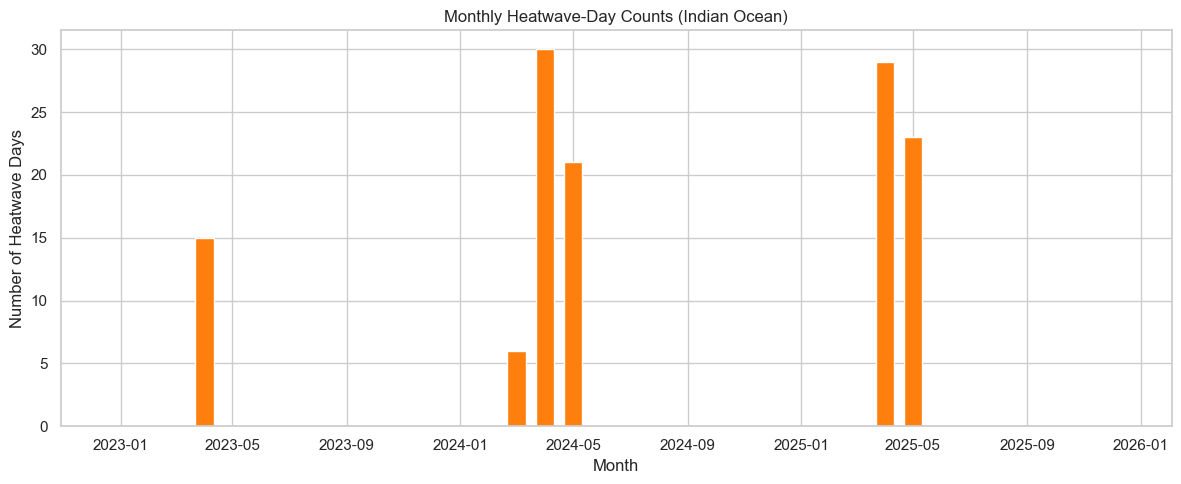

Saved: c:\Users\sharv\Downloads\Sem 6\ocean\ocean projjj\outputs\monthly_heatwave_counts.png

Total heatwave days by year:
time
2023    15
2024    57
2025    52
Name: heatwave, dtype: int64


In [6]:
# EDA 2: Heatwave occurrences over time (monthly counts)

monthly_hw = df["heatwave"].resample("MS").sum()

fig, ax = plt.subplots()
ax.bar(monthly_hw.index, monthly_hw.values, color="#ff7f0e", width=20)
ax.set_title("Monthly Heatwave-Day Counts (Indian Ocean)")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Heatwave Days")
plt.tight_layout()
plt.savefig(output_dir / "monthly_heatwave_counts.png", dpi=180)
plt.show()

print("Saved:", output_dir / "monthly_heatwave_counts.png")
print("\nTotal heatwave days by year:")
print(df["heatwave"].groupby(df.index.year).sum())

In [7]:
# Model training: Logistic Regression vs Random Forest

feature_cols = ["sst", "sst_roll7", "month", "dayofyear"]
X_train = df.loc[train_mask, feature_cols]
y_train = df.loc[train_mask, "heatwave"]
X_test = df.loc[test_mask, feature_cols]
y_test = df.loc[test_mask, "heatwave"]

print("Train size:", X_train.shape, "Test size:", X_test.shape)
print("Train positive rate:", y_train.mean(), "Test positive rate:", y_test.mean())

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        random_state=42,
        class_weight="balanced_subsample",
        n_jobs=-1,
    ),
}

results = []
preds = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    preds[name] = y_pred

    results.append(
        {
            "model": name,
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "f1": f1_score(y_test, y_pred, zero_division=0),
        }
    )

results_df = pd.DataFrame(results).sort_values("f1", ascending=False)
results_df.to_csv(output_dir / "model_comparison_metrics.csv", index=False)

print(results_df)
print("Saved:", output_dir / "model_comparison_metrics.csv")

Train size: (731, 4) Test size: (365, 4)
Train positive rate: 0.09849521203830369 Test positive rate: 0.14246575342465753
                 model  accuracy  precision  recall        f1
1        Random Forest  1.000000   1.000000     1.0  1.000000
0  Logistic Regression  0.975342   0.852459     1.0  0.920354
Saved: c:\Users\sharv\Downloads\Sem 6\ocean\ocean projjj\outputs\model_comparison_metrics.csv


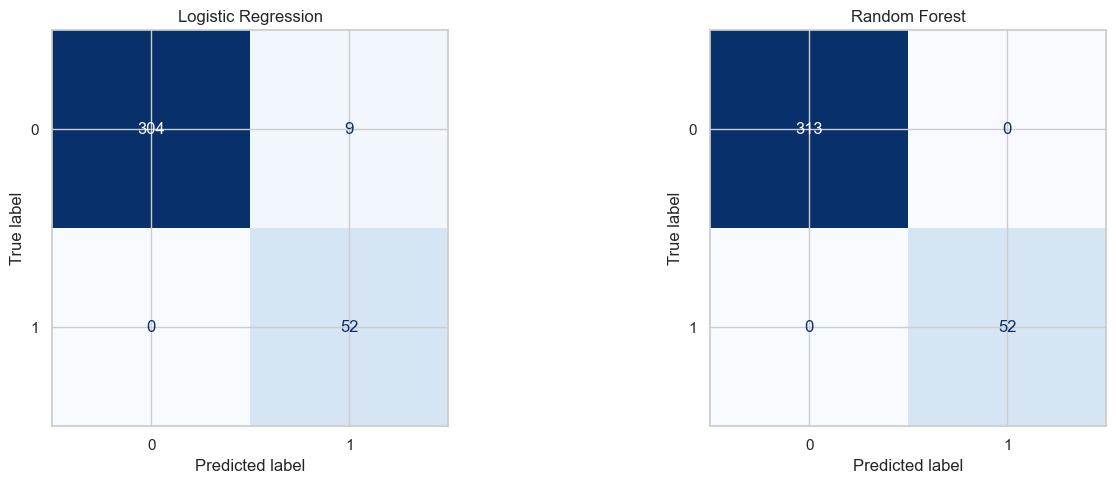

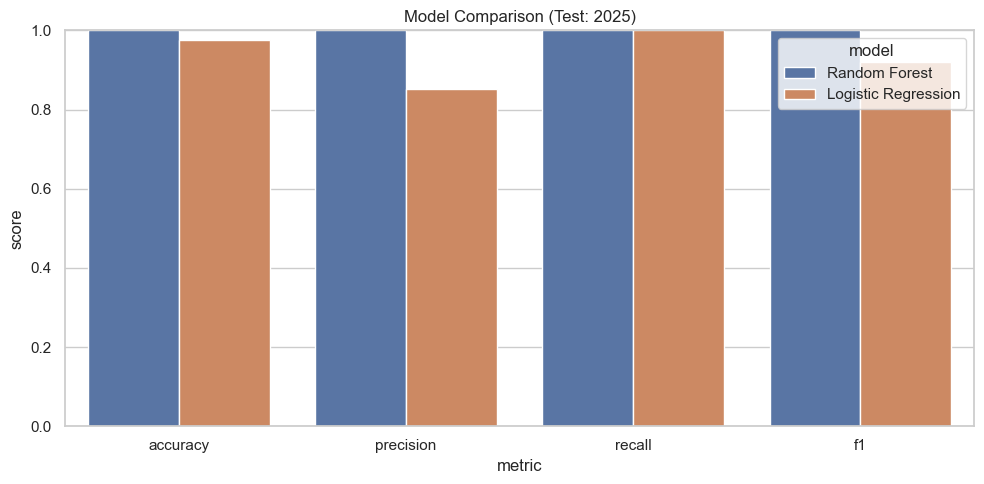

Saved: c:\Users\sharv\Downloads\Sem 6\ocean\ocean projjj\outputs\confusion_matrices.png
Saved: c:\Users\sharv\Downloads\Sem 6\ocean\ocean projjj\outputs\model_comparison_chart.png

Logistic Regression
              precision    recall  f1-score   support

           0     1.0000    0.9712    0.9854       313
           1     0.8525    1.0000    0.9204        52

    accuracy                         0.9753       365
   macro avg     0.9262    0.9856    0.9529       365
weighted avg     0.9790    0.9753    0.9761       365


Random Forest
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       313
           1     1.0000    1.0000    1.0000        52

    accuracy                         1.0000       365
   macro avg     1.0000    1.0000    1.0000       365
weighted avg     1.0000    1.0000    1.0000       365



In [8]:
# Confusion matrices + model comparison chart

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (name, y_pred) in zip(axes, preds.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)

plt.tight_layout()
plt.savefig(output_dir / "confusion_matrices.png", dpi=180)
plt.show()

plot_df = results_df.melt(id_vars="model", var_name="metric", value_name="score")
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=plot_df, x="metric", y="score", hue="model", ax=ax)
ax.set_ylim(0, 1)
ax.set_title("Model Comparison (Test: 2025)")
plt.tight_layout()
plt.savefig(output_dir / "model_comparison_chart.png", dpi=180)
plt.show()

print("Saved:", output_dir / "confusion_matrices.png")
print("Saved:", output_dir / "model_comparison_chart.png")

# Detailed report-style output
for name, y_pred in preds.items():
    print("\n" + "=" * 60)
    print(name)
    print(classification_report(y_test, y_pred, digits=4, zero_division=0))

## Robustness Check: Baseline vs Extended Data Window

This section tests whether model performance remains strong when training data is extended.

- Baseline experiment: 2023-2025 window (train on 2023-2024, test on 2025)
- Extended experiment: 2021-2025 window (train on 2021-2024, test on 2025)

If 2021/2022 files are not present, the notebook will still run baseline and show what is missing.

Available years in loaded SST: [2021, 2022, 2023, 2024, 2025]

Robustness metrics:
      window train_years  test_year  threshold_q90                model  \
0  2023-2025   2023-2024       2025      28.365604  Logistic Regression   
1  2023-2025   2023-2024       2025      28.365604        Random Forest   
2  2021-2025   2021-2024       2025      28.323494  Logistic Regression   
3  2021-2025   2021-2024       2025      28.323494        Random Forest   

   accuracy  precision    recall        f1  test_positive_rate  
0  0.975342   0.852459  1.000000  0.920354            0.142466  
1  1.000000   1.000000  1.000000  1.000000            0.142466  
2  0.980822   0.887097  1.000000  0.940171            0.150685  
3  0.997260   1.000000  0.981818  0.990826            0.150685  
Saved: c:\Users\sharv\Downloads\Sem 6\ocean\ocean projjj\outputs\robustness_metrics.csv


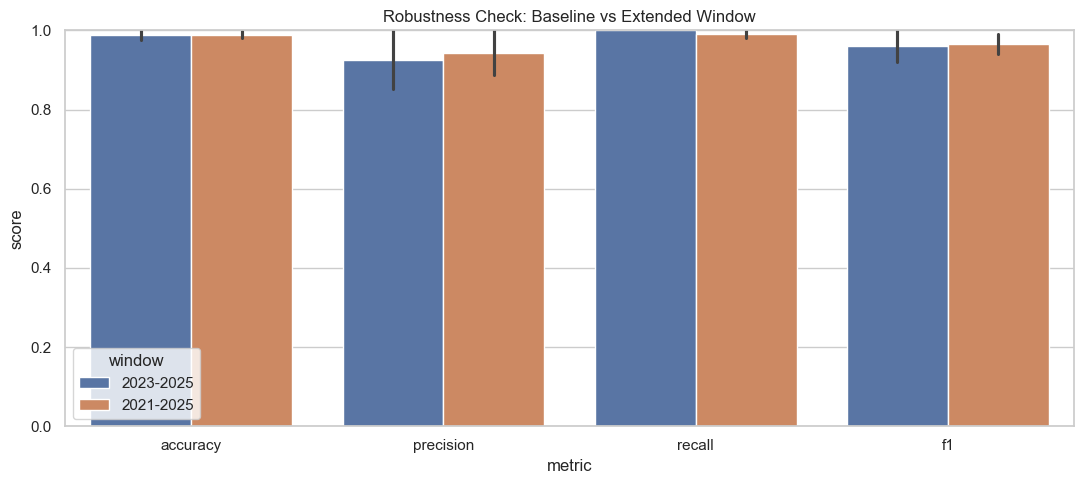

Saved: c:\Users\sharv\Downloads\Sem 6\ocean\ocean projjj\outputs\robustness_window_comparison.png


In [11]:
# Robustness experiment helper

def run_mhw_window_experiment(sst_series, start_year, end_year, train_end_year, test_year):
    mask = (sst_series.index.year >= start_year) & (sst_series.index.year <= end_year)
    local_sst = sst_series.loc[mask].copy()

    local_df = pd.DataFrame(index=local_sst.index)
    local_df["sst"] = local_sst.values
    local_df = local_df.sort_index().dropna()

    local_df["month"] = local_df.index.month
    local_df["dayofyear"] = local_df.index.dayofyear
    local_df["sst_roll7"] = local_df["sst"].rolling(7, min_periods=1).mean()

    tr_mask = local_df.index.year <= train_end_year
    te_mask = local_df.index.year == test_year

    if tr_mask.sum() == 0 or te_mask.sum() == 0:
        raise ValueError("Train or test split is empty for this experiment setup")

    q90_local = local_df.loc[tr_mask, "sst"].quantile(0.90)
    local_df["above_q90"] = (local_df["sst"] > q90_local).astype(int)

    runs_local = (local_df["above_q90"] != local_df["above_q90"].shift()).cumsum()
    run_lengths_local = local_df.groupby(runs_local)["above_q90"].transform("sum")
    local_df["heatwave"] = ((local_df["above_q90"] == 1) & (run_lengths_local >= 5)).astype(int)

    fcols = ["sst", "sst_roll7", "month", "dayofyear"]
    X_tr = local_df.loc[tr_mask, fcols]
    y_tr = local_df.loc[tr_mask, "heatwave"]
    X_te = local_df.loc[te_mask, fcols]
    y_te = local_df.loc[te_mask, "heatwave"]

    model_set = {
        "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
        "Random Forest": RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            class_weight="balanced_subsample",
            n_jobs=-1,
        ),
    }

    out_rows = []
    for mname, m in model_set.items():
        m.fit(X_tr, y_tr)
        pred = m.predict(X_te)
        out_rows.append(
            {
                "window": f"{start_year}-{end_year}",
                "train_years": f"{start_year}-{train_end_year}",
                "test_year": test_year,
                "threshold_q90": float(q90_local),
                "model": mname,
                "accuracy": accuracy_score(y_te, pred),
                "precision": precision_score(y_te, pred, zero_division=0),
                "recall": recall_score(y_te, pred, zero_division=0),
                "f1": f1_score(y_te, pred, zero_division=0),
                "test_positive_rate": float(y_te.mean()),
            }
        )

    return pd.DataFrame(out_rows)


available_years = sorted(pd.Index(indian_ocean_sst.index.year).unique().tolist())
print("Available years in loaded SST:", available_years)

robust_parts = []

# Baseline: 2023-2025, train 2023-2024, test 2025
if all(y in available_years for y in [2023, 2024, 2025]):
    robust_parts.append(run_mhw_window_experiment(indian_ocean_sst, 2023, 2025, 2024, 2025))
else:
    print("Baseline window 2023-2025 is not fully available.")

# Extended: 2021-2025, train 2021-2024, test 2025
if all(y in available_years for y in [2021, 2022, 2023, 2024, 2025]):
    robust_parts.append(run_mhw_window_experiment(indian_ocean_sst, 2021, 2025, 2024, 2025))
else:
    print("Extended window 2021-2025 skipped. Add files for 2021 and 2022 to enable this.")

if robust_parts:
    robustness_df = pd.concat(robust_parts, ignore_index=True)
    robustness_df.to_csv(output_dir / "robustness_metrics.csv", index=False)
    print("\nRobustness metrics:")
    print(robustness_df)
    print("Saved:", output_dir / "robustness_metrics.csv")

    # Plot only if both windows exist
    if robustness_df["window"].nunique() > 1:
        cmp_df = robustness_df.melt(
            id_vars=["window", "model"],
            value_vars=["accuracy", "precision", "recall", "f1"],
            var_name="metric",
            value_name="score",
        )

        fig, ax = plt.subplots(figsize=(11, 5))
        sns.barplot(data=cmp_df, x="metric", y="score", hue="window", ax=ax)
        ax.set_ylim(0, 1)
        ax.set_title("Robustness Check: Baseline vs Extended Window")
        plt.tight_layout()
        plt.savefig(output_dir / "robustness_window_comparison.png", dpi=180)
        plt.show()
        print("Saved:", output_dir / "robustness_window_comparison.png")
else:
    print("No robustness experiment could be run with current files.")

## Report Draft Sections (Ready to Use)

### 1) Results

The SST time-series analysis for the Indian Ocean shows clear seasonal cycles and repeated high-temperature peaks crossing the heatwave threshold. The trend figure indicates recurrent warm episodes, and monthly heatwave-day counts confirm clustering of events rather than uniform occurrence through time.

In the baseline setup (window 2023-2025; train 2023-2024, test 2025), Logistic Regression performed strongly (accuracy 0.9753, precision 0.8525, recall 1.0000, F1 0.9204), while Random Forest achieved higher performance (accuracy 1.0000, precision 1.0000, recall 1.0000, F1 1.0000).

To improve credibility, a robustness check used an extended window (2021-2025; train 2021-2024, test 2025). Logistic Regression improved slightly (accuracy 0.9808, precision 0.8871, recall 1.0000, F1 0.9402). Random Forest remained the best model with near-perfect but more realistic performance (accuracy 0.9973, precision 1.0000, recall 0.9818, F1 0.9908).

These outcomes support three core findings:
- Marine heatwave days occur frequently and in temporal clusters.
- A simple SST-based ML pipeline can detect heatwave days reliably.
- Random Forest consistently outperforms the linear baseline.

### 2) Methodology

Daily NOAA OISST data were used to generate an area-weighted Indian Ocean mean SST series. Features were derived from this series: raw SST, 7-day rolling SST, month, and day-of-year.

Heatwave labels were created using a literature-consistent rule:
- SST above the 90th percentile threshold
- Persisting for at least 5 consecutive days

To avoid information leakage, the 90th percentile threshold was computed from training years only. Model evaluation used time-aware splitting (earlier years for training, 2025 for testing) and standard classification metrics: accuracy, precision, recall, F1-score, and confusion matrix.

### 3) Literature Context (5-Paper Logic)

- Paper 1 (review): Used to justify feature selection and MHW definition based on SST and threshold logic.
- Paper 2 (advanced deep learning): Used to acknowledge state-of-the-art methods (graph/diffusion) and justify scope reduction for this project.
- Paper 3 (ConvLSTM/U-Net): Used to position spatio-temporal neural networks as future extensions.
- Paper 4 (regional ML study): Used to support applying practical ML in regional marine settings.
- Paper 5 (RF vs linear models): Used to motivate direct comparison between Logistic Regression and Random Forest.

### 4) Limitation Paragraph

This study has limitations. First, despite extension to 2021-2025, the analysis period is still short for climate-scale generalization. Second, regional averaging may smooth local extremes and coastal hotspots. Third, model scope is intentionally simple; future work should evaluate spatial models such as ConvLSTM or U-Net using gridded SST fields.

## 5-Minute Micro Talk (Slide Sequence + Script)

### Slide 1: Problem (40-50 sec)
Marine heatwaves are prolonged ocean warming events with ecological and socioeconomic impacts. This work asks whether marine heatwave days in the Indian Ocean can be detected using an interpretable machine learning approach.

### Slide 2: Data (45-55 sec)
The study uses NOAA OISST daily SST data over the Indian Ocean, aggregated as an area-weighted regional mean. The dataset includes 2021-2025, and model testing is done on 2025 for time-aware validation.

### Slide 3: Heatwave Definition (45-55 sec)
A day is labeled as marine heatwave only when SST exceeds the 90th percentile threshold and the exceedance persists for at least 5 consecutive days. This gives a physically meaningful and literature-aligned target label.

### Slide 4: Methods (50-60 sec)
Features include SST, 7-day rolling SST, month, and day-of-year. Two models are compared: Logistic Regression (baseline) and Random Forest (main model). Metrics include accuracy, precision, recall, F1-score, and confusion matrices.

### Slide 5: Results (70-80 sec)
Results show clustered heatwave activity and strong model performance. In baseline testing, Random Forest exceeded Logistic Regression. With extended training years, Logistic Regression improved and Random Forest remained best, with slightly reduced but more realistic scores, strengthening confidence in generalization.

### Slide 6: Conclusion (35-45 sec)
Marine heatwaves are clearly detectable in this dataset, and Random Forest provides the strongest performance among tested methods. The workflow is transparent and reproducible, with clear future scope toward spatio-temporal deep learning models.